In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

red['type'] = 'red'
white['type'] = 'white'

data = pd.concat([red, white], ignore_index=True)

print("\nColumns in combined dataset:")
print(data.columns)
print(data.head)


Columns in combined dataset:
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'type'],
      dtype='object')
<bound method NDFrame.head of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4              0.70         0.00             1.9      0.076   
1               7.8              0.88         0.00             2.6      0.098   
2               7.8              0.76         0.04             2.3      0.092   
3              11.2              0.28         0.56             1.9      0.075   
4               7.4              0.70         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
6492            6.2              0.21         0.29             1.6      0.039   
6493            6.6              0.32         0.36        

In [ ]:
X = data.drop(['quality', 'type'], axis=1)
y = data['quality']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

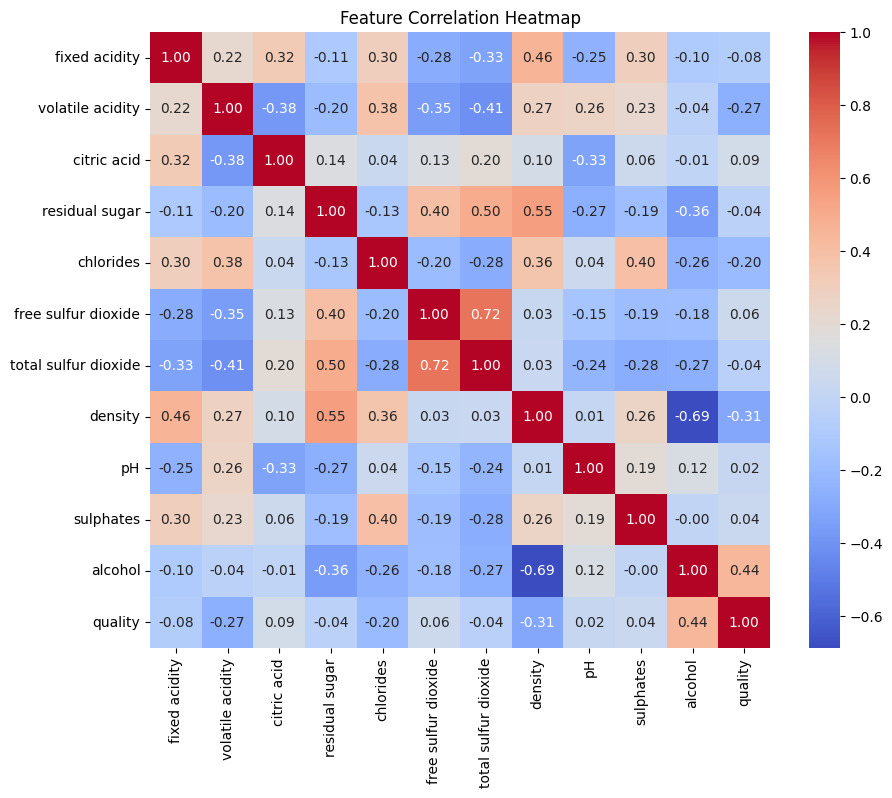

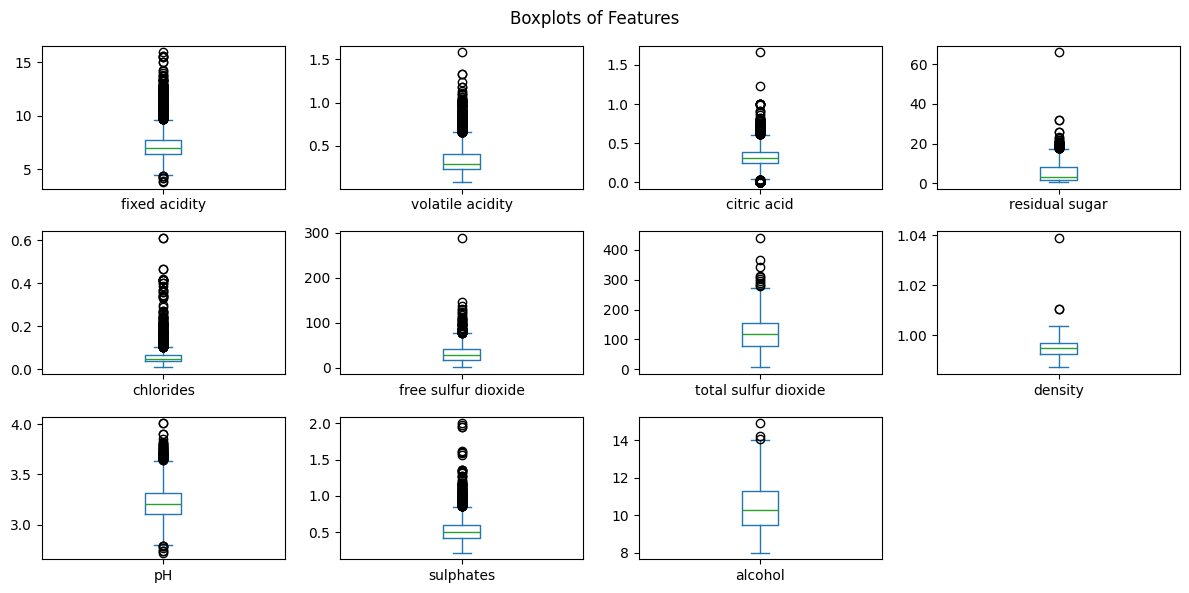

In [ ]:
import seaborn as sns

numeric_data = data.select_dtypes(include=[np.number])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

numeric_data.drop(['quality'], axis=1).plot(kind='box', figsize=(12,6), subplots=True, layout=(3,4), sharex=False, sharey=False)
plt.suptitle("Boxplots of Features")
plt.tight_layout()
plt.show()


PC1: Explained Variance = 0.2535, Cumulative = 0.2535
PC2: Explained Variance = 0.2208, Cumulative = 0.4743
PC3: Explained Variance = 0.1368, Cumulative = 0.6111
PC4: Explained Variance = 0.0891, Cumulative = 0.7001
PC5: Explained Variance = 0.0700, Cumulative = 0.7702
PC6: Explained Variance = 0.0550, Cumulative = 0.8252
PC7: Explained Variance = 0.0470, Cumulative = 0.8722
PC8: Explained Variance = 0.0430, Cumulative = 0.9152
PC9: Explained Variance = 0.0382, Cumulative = 0.9534
PC10: Explained Variance = 0.0249, Cumulative = 0.9783
PC11: Explained Variance = 0.0190, Cumulative = 0.9973
PC12: Explained Variance = 0.0027, Cumulative = 1.0000


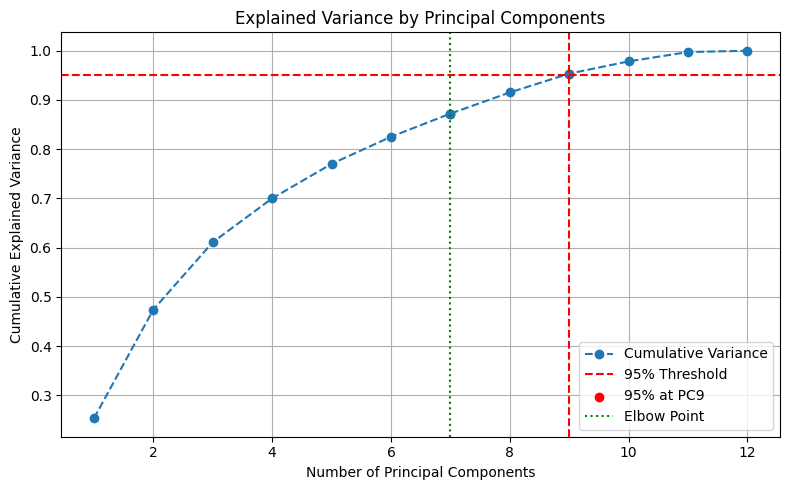

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance), start=1):
    print(f"PC{i}: Explained Variance = {ev:.4f}, Cumulative = {cv:.4f}")

k_95 = np.argmax(cumulative_variance >= 0.95) + 1
differences = np.diff(cumulative_variance, 2)
elbow = np.argmax(differences) + 2

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--', label='Cumulative Variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.axvline(x=k_95, color='r', linestyle='--')
plt.scatter(k_95, cumulative_variance[k_95 - 1], color='red', label=f'95% at PC{k_95}')
plt.axvline(x=elbow, color='g', linestyle=':', label='Elbow Point')
plt.scatter(elbow, cumulative_variance[elbow - 1], color='green')

plt.title('Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


First 5 rows of transformed data (after PCA):
 [[-3.20599617  0.41652332 -2.72223659 -0.79677754 -0.2028775  -0.2273628
  -0.32555356 -0.56727848 -0.07122889 -0.10804627  0.0274601 ]
 [-3.03905081  1.10746213 -2.04695235 -0.77022492  1.32265539  1.65512149
   0.05955866 -0.51460258  0.42912861 -0.26814891 -0.01547136]
 [-3.07189347  0.87896444 -1.74257961 -0.80225727  0.76211171  0.84837359
   0.16766964 -0.42095243  0.27103173 -0.08683191  0.05414596]
 [-1.57126214  2.11254455  2.59291702 -0.29278451 -0.60470078 -0.71330815
  -0.85121712 -0.9296686  -0.54940958  0.11665967 -0.1037447 ]
 [-3.20599617  0.41652332 -2.72223659 -0.79677754 -0.2028775  -0.2273628
  -0.32555356 -0.56727848 -0.07122889 -0.10804627  0.0274601 ]]


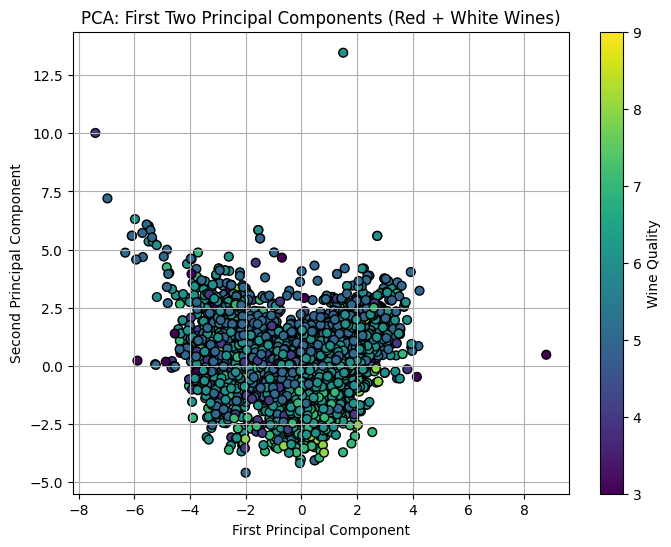

In [ ]:
print("First 5 rows of transformed data (after PCA):\n", X_pca[:5])


plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis', edgecolor='k', s=40)
plt.title('PCA: First Two Principal Components (Red + White Wines)')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.colorbar(label='Wine Quality')
plt.grid()
plt.show()


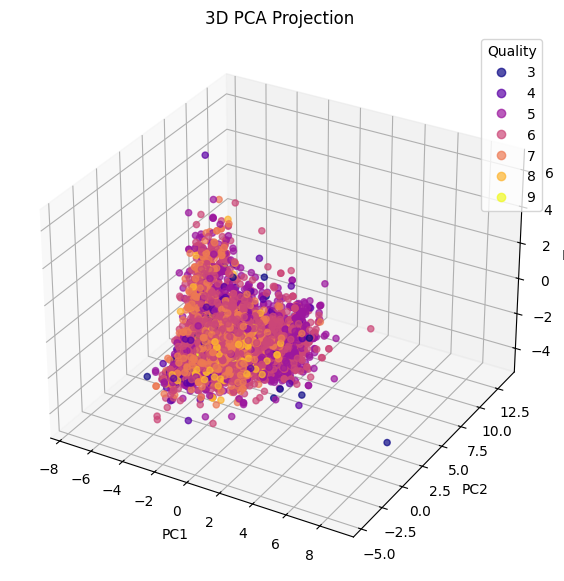

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=y, cmap='plasma', alpha=0.7)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('3D PCA Projection')
plt.legend(*scatter.legend_elements(), title='Quality')
plt.show()

sklearn PCA: Transformed Shape: (6497, 2)
First 5 rows of Transformed Data (sklearn):
 [[-3.34843817  0.56892617]
 [-3.22859545  1.19733465]
 [-3.23746833  0.95258001]
 [-1.67256055  1.60058297]
 [-3.34843817  0.56892617]]
Manual PCA: Transformed Shape: (6497, 2)
First 5 rows of Transformed Data (Manual):
 [[-3.34843817  0.56892617]
 [-3.22859545  1.19733465]
 [-3.23746833  0.95258001]
 [-1.67256055  1.60058297]
 [-3.34843817  0.56892617]]


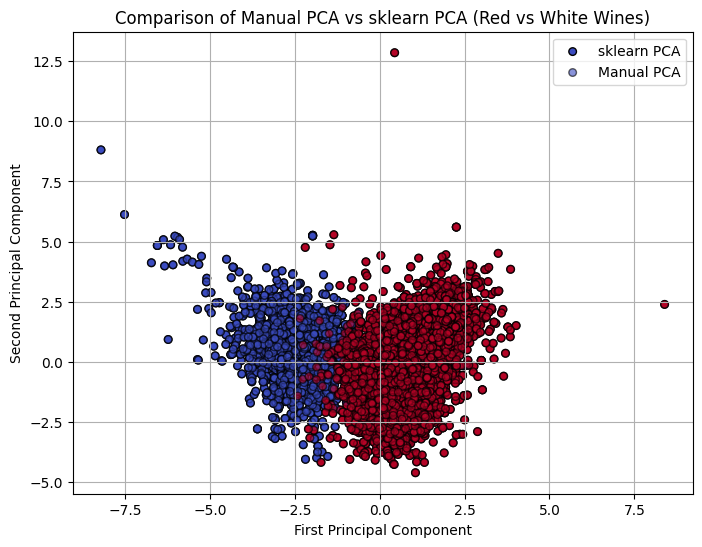

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

red_wine = pd.read_csv('winequality-red.csv', sep=';')
white_wine = pd.read_csv('winequality-white.csv', sep=';')

red_wine['type'] = 'red'
white_wine['type'] = 'white'

data = pd.concat([red_wine, white_wine], axis=0)

X = data.drop('type', axis=1).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_sklearn = PCA(n_components=2)
X_pca_sklearn = pca_sklearn.fit_transform(X_scaled)

print("sklearn PCA: Transformed Shape:", X_pca_sklearn.shape)
print("First 5 rows of Transformed Data (sklearn):\n", X_pca_sklearn[:5])

def fit_pca(X, n_components):
    X_scaled = StandardScaler().fit_transform(X)

    cov_matrix = np.cov(X_scaled, rowvar=False)

    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]

    components = eigenvectors[:, :n_components]

    return components

def transform_pca(X, components):
    X_scaled = StandardScaler().fit_transform(X)
    return np.dot(X_scaled, components)

components_manual = fit_pca(X, 2)
X_pca_manual = transform_pca(X, components_manual)

print("Manual PCA: Transformed Shape:", X_pca_manual.shape)
print("First 5 rows of Transformed Data (Manual):\n", X_pca_manual[:5])

wine_colors = data['type'].map({'red': 0, 'white': 1})

plt.figure(figsize=(8, 6))

plt.scatter(X_pca_sklearn[:, 0], X_pca_sklearn[:, 1], c=wine_colors, cmap='coolwarm', edgecolor='k', s=30, label='sklearn PCA')

plt.scatter(X_pca_manual[:, 0], X_pca_manual[:, 1], c=wine_colors, cmap='coolwarm', edgecolor='k', s=30, alpha=0.6, label='Manual PCA')

plt.title('Comparison of Manual PCA vs sklearn PCA (Red vs White Wines)')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

plt.legend(loc='best')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
accuracy_pre_pca = accuracy_score(y_test, y_pred)

pca = PCA(0.95)
X_pca = pca.fit_transform(X_scaled)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.3, random_state=42)
logreg_pca = LogisticRegression(max_iter=1000)
logreg_pca.fit(X_train_pca, y_train_pca)
y_pred_pca = logreg_pca.predict(X_test_pca)
accuracy_post_pca = accuracy_score(y_test_pca, y_pred_pca)

print(f"Accuracy before PCA: {accuracy_pre_pca * 100:.2f}%")
print(f"Accuracy after PCA (95% variance retained): {accuracy_post_pca * 100:.2f}%")
print(f"Number of components used after PCA: {pca.n_components_}")

cm_before = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix Before PCA:")
print(cm_before)

cm_after = confusion_matrix(y_test_pca, y_pred_pca)
print("\nConfusion Matrix After PCA:")
print(cm_after)


Accuracy before PCA: 99.59%
Accuracy after PCA (95% variance retained): 98.87%
Number of components used after PCA: 9

Confusion Matrix Before PCA:
[[  4   5   0   0   0   0   0]
 [  0  67   2   0   0   0   0]
 [  0   0 613   0   0   0   0]
 [  0   0   0 894   0   0   0]
 [  0   0   0   0 315   0   0]
 [  0   0   0   0   0  49   0]
 [  0   0   0   0   0   1   0]]

Confusion Matrix After PCA:
[[  1   7   1   0   0   0   0]
 [  0  63   6   0   0   0   0]
 [  0   0 610   3   0   0   0]
 [  0   0   3 891   0   0   0]
 [  0   0   0   0 315   0   0]
 [  0   0   0   0   1  48   0]
 [  0   0   0   0   0   1   0]]


First 5 rows of Transformed Data (Fully Manual PCA):
 [[-3.34843817  0.56892617]
 [-3.22859545  1.19733465]
 [-3.23746833  0.95258001]
 [-1.67256055  1.60058297]
 [-3.34843817  0.56892617]]


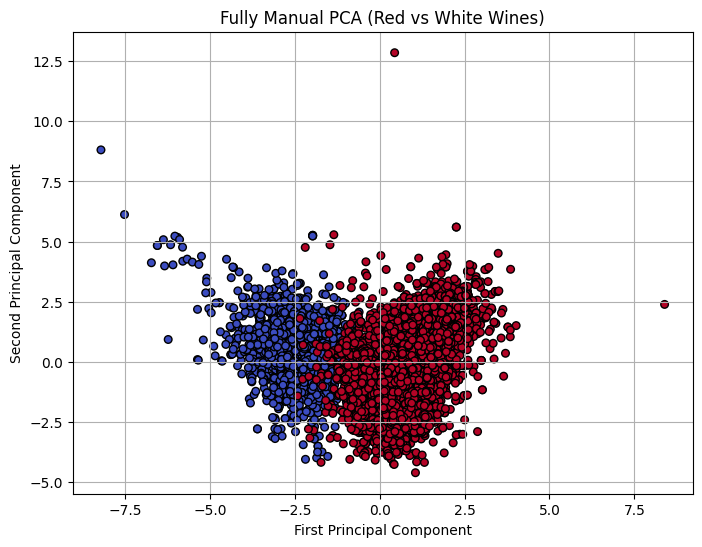

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load and prepare the data
red_wine = pd.read_csv('winequality-red.csv', sep=';')
white_wine = pd.read_csv('winequality-white.csv', sep=';')

red_wine['type'] = 'red'
white_wine['type'] = 'white'
data = pd.concat([red_wine, white_wine], axis=0)
X = data.drop('type', axis=1).values

# Fully manual PCA
def manual_pca(X, n_components):
    # Step 1: Manual standardization
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    X_scaled = (X - mean) / std

    # Step 2: Compute covariance matrix
    cov_matrix = np.cov(X_scaled, rowvar=False)

    # Step 3: Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    # Step 4: Sort eigenvalues and eigenvectors
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvectors = eigenvectors[:, sorted_indices]

    # Step 5: Select top n_components
    components = eigenvectors[:, :n_components]

    # Step 6: Project data
    X_pca = np.dot(X_scaled, components)

    return X_pca

# Apply manual PCA
X_pca_fully_manual = manual_pca(X, 2)

# Print the first 5 rows of the transformed data
print("First 5 rows of Transformed Data (Fully Manual PCA):\n", X_pca_fully_manual[:5])

# Plot results
wine_colors = data['type'].map({'red': 0, 'white': 1})

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_fully_manual[:, 0], X_pca_fully_manual[:, 1], c=wine_colors, cmap='coolwarm', edgecolor='k', s=30)
plt.title('Fully Manual PCA (Red vs White Wines)')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.grid(True)
plt.show()
